# 04 — Forecasting Comparison (axe Usage Mining)

**Owner** : **Bachirou Konaté**

Étude comparative §N2.3 du PRD — **CRITIQUE pour le jury**.

## Modèles évalués

1. **ARIMA** (`statsmodels`, auto-fit AIC sur grille (p,d,q))
2. **Prophet** (Meta, ex-Facebook)
3. **LSTM** (`neuralforecast`, encoder léger 16 unités, 1 couche)

## Métriques

- **RMSE** (Root Mean Squared Error) — métrique principale, robuste aux zéros
- **MAE** (Mean Absolute Error)
- **MAPE** (Mean Absolute Percentage Error) — calculé uniquement sur actual ≥ 5 pour éviter l'explosion
- **Runtime** par modèle
- **Couverture IC 95%** — % de valeurs réelles dans l'intervalle de confiance prédit

## Protocole

- Top 10 compétences par occurrence dans le corpus 3 468 offres
- Séries temporelles **hebdomadaires** (lundi → lundi suivant)
- Fenêtre : **janvier → avril 2026 (16 semaines)**
- **Note** : les 3 dernières semaines (27 avril → 17 mai) sont exclues car partiellement incomplètes (scraping mi-mai 2026), pour éviter un biais de zéros artificiels dans le test set
- Train : **12 semaines**, Test : **4 semaines** (≈ 1 mois)
- Forecast futur : 4 semaines après la fin des données (mai 2026)

## Section du rapport L5 alimentée

§4.3 Forecasting comparé + §3.5 Pipeline Usage Mining.

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings('ignore')

import json
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Silencer pytorch_lightning + prophet (logs verbeux)
for name in ['pytorch_lightning', 'lightning_fabric', 'neuralforecast', 'prophet', 'cmdstanpy']:
    logging.getLogger(name).setLevel(logging.ERROR)

from skillnav.pipelines.usage_mining.series_builder import build_time_series
from skillnav.pipelines.usage_mining.comparison import (
    aggregate_metrics,
    run_all,
)

Path('../data/exports').mkdir(parents=True, exist_ok=True)
print('Setup OK')

Setup OK


## 1. Construction des séries temporelles

Top 10 compétences par nombre d'occurrences dans le corpus. Bucketing hebdomadaire (lundi de chaque semaine ISO).

In [2]:
series_list = build_time_series(top_n=10)

print(f'Séries construites : {len(series_list)}')
print(f'Plage temporelle   : {series_list[0].data_points[0].period} → {series_list[0].data_points[-1].period}')
print(f'Nb semaines        : {len(series_list[0].data_points)}\n')
print(f"{'Skill':<25} {'Total':>6} {'Min':>5} {'Max':>5} {'Famille'}")
print('-' * 75)
for s in series_list:
    counts = [d.count for d in s.data_points]
    print(f'{s.skill_name:<25} {sum(counts):>6} {min(counts):>5} {max(counts):>5}  [{s.family}]')

Séries construites : 10
Plage temporelle   : 2026-01-05 → 2026-04-20
Nb semaines        : 16

Skill                      Total   Min   Max Famille
---------------------------------------------------------------------------
Prompt engineering          1148    22   110  [GenAI]
RAG                         1043    19   106  [Agents AI]
LangChain                    724    12    79  [GenAI]
PyTorch                      688     8    76  [Deep Learning]
LLMs                         595     5    72  [GenAI]
TensorFlow                   482     5    55  [Deep Learning]
LangGraph                    390     7    45  [Agents AI]
Fine-tuning                  287     7    47  [GenAI]
OpenAI API                   286     6    28  [GenAI]
embeddings                   282     3    30  [GenAI]


## 2. Visualisation des séries

Aperçu graphique des 10 séries temporelles.

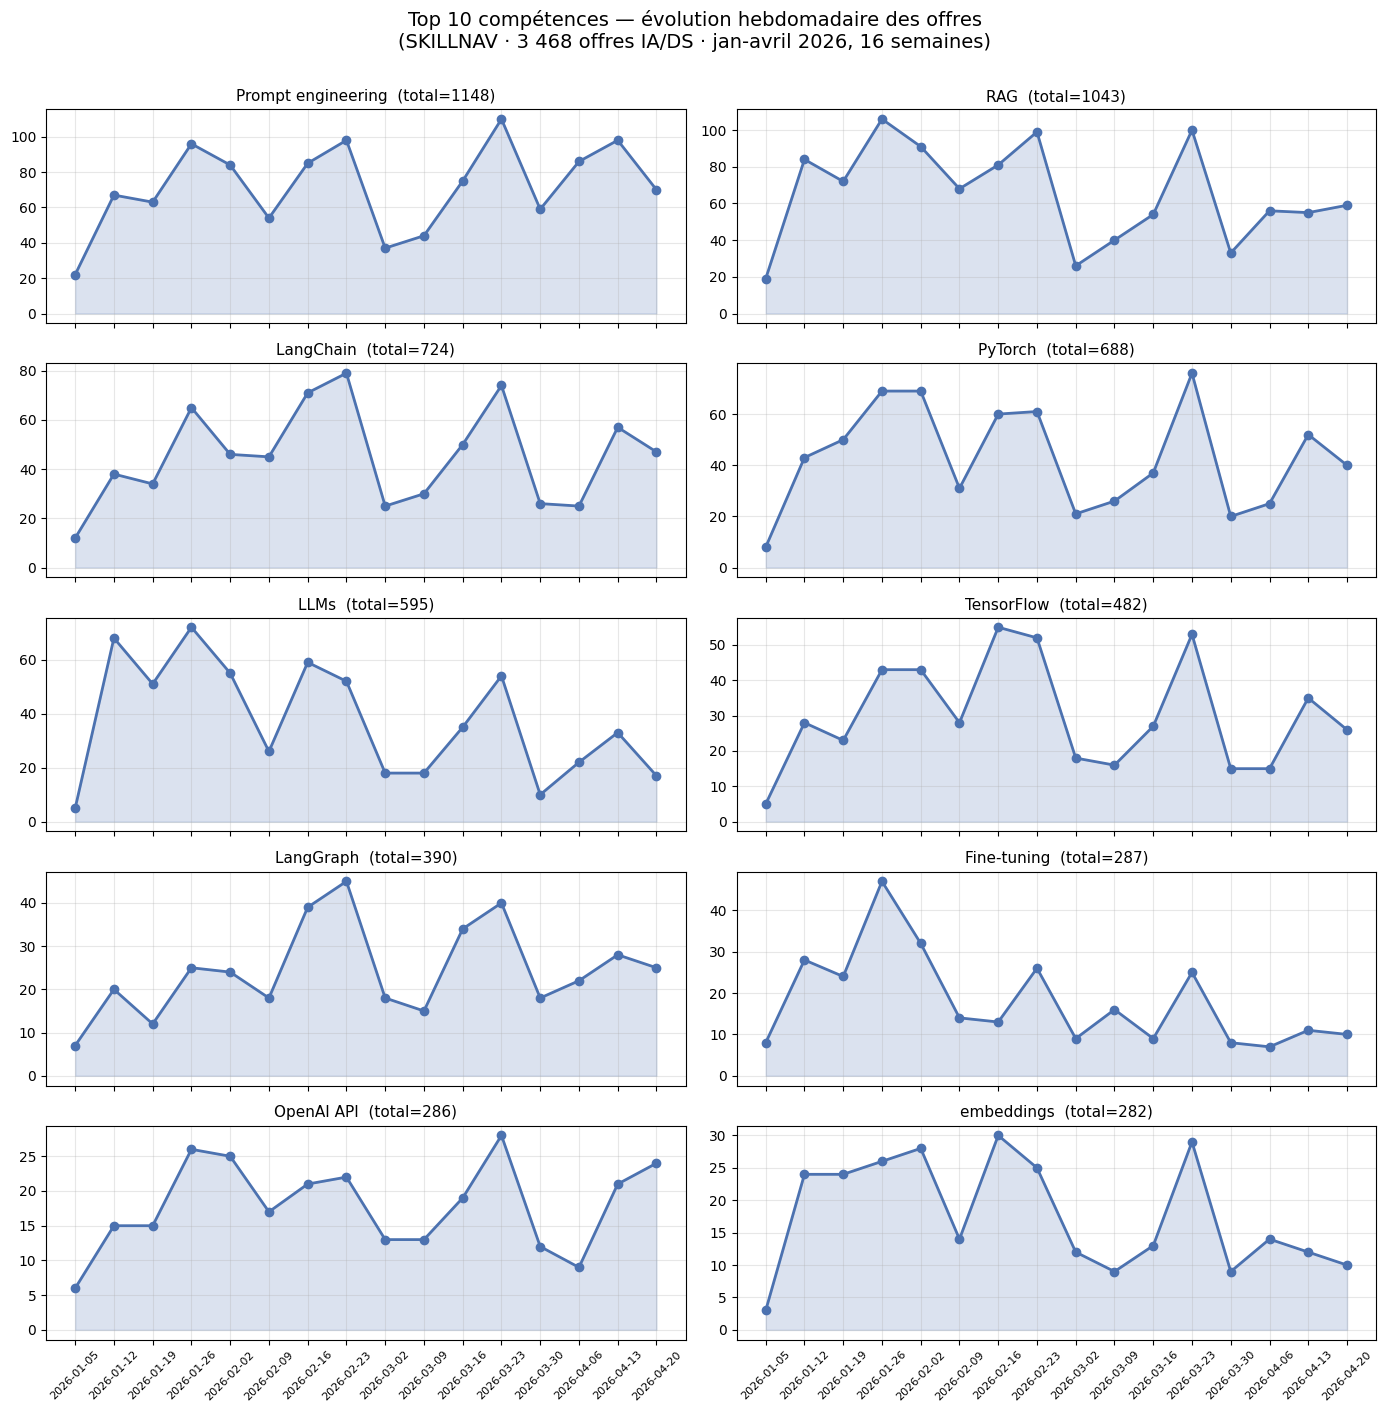

Sauvegardé : data/exports/forecast_series_top10.png


In [3]:
fig, axes = plt.subplots(5, 2, figsize=(14, 14), sharex=True)
axes = axes.flatten()

for ax, s in zip(axes, series_list):
    weeks = [d.period for d in s.data_points]
    counts = [d.count for d in s.data_points]
    ax.plot(weeks, counts, marker='o', linewidth=2, color='#4C72B0')
    ax.fill_between(weeks, counts, alpha=0.2, color='#4C72B0')
    ax.set_title(f'{s.skill_name}  (total={sum(counts)})', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Top 10 compétences — évolution hebdomadaire des offres\n(SKILLNAV · 3 468 offres IA/DS · jan-avril 2026, 16 semaines)',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig('../data/exports/forecast_series_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : data/exports/forecast_series_top10.png')

## 3. Étude comparative — exécution des 3 modèles

Pour chaque compétence :
1. Train sur **12 semaines**, test sur 4 semaines (4 dernières)
2. Calcul des métriques RMSE / MAE / MAPE / runtime / couverture IC 95%
3. Re-entraînement sur toute la série + forecast 4 semaines futur (mai 2026)

Durée totale estimée : 6 à 10 minutes (LSTM est le plus lent).

In [4]:
results = run_all(series_list, train_periods=12, test_periods=4, horizon=4)
print(f'\n{len(results)} comparaisons terminées.')

  [ 1/10] Prompt engineering


Importing plotly failed. Interactive plots will not work.


14:41:24 - cmdstanpy - INFO - Chain [1] start processing


14:41:29 - cmdstanpy - INFO - Chain [1] done processing


2026-05-18 14:41:59,808	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


...


  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 1.2 K  | train
4 | mlp_decoder  | MLP           | 2.3 K  | train
-------------------------------------------------------
3.5 K     Trainable params
0         Non-trainable params
3.5 K     Total params
0.014     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=200` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



10 comparaisons terminées.


## 4. Tableau des métriques par skill

In [5]:
rows = []
for r in results:
    for m in [r.metrics_arima, r.metrics_prophet, r.metrics_lstm]:
        rows.append({
            'Skill': r.skill_name,
            'Modèle': m.method.value,
            'RMSE': round(m.rmse, 2),
            'MAE': round(m.mae, 2),
            'MAPE (%)': round(m.mape, 1) if m.mape is not None else None,
            'Runtime (s)': round(m.runtime, 2),
            'Couv. IC95% (%)': round(m.coverage_95, 0),
            'Gagnant ?': '★' if r.best_method.value == m.method.value else '',
        })

df_full = pd.DataFrame(rows)
df_full

,Skill,Modèle,RMSE,MAE,MAPE (%),Runtime (s),Couv. IC95% (%),Gagnant ?
0,Prompt engineering,ARIMA,17.24,13.96,16.7,4.85,100.0,★
1,Prompt engineering,Prophet,17.60,14.46,21.5,5.69,100.0,
2,Prompt engineering,LSTM,50.74,47.72,63.0,14.45,100.0,
3,RAG,ARIMA,21.85,19.24,45.7,6.24,100.0,★
4,RAG,Prophet,22.65,20.21,47.7,0.46,100.0,
5,RAG,LSTM,45.25,44.47,89.1,15.79,100.0,
6,LangChain,ARIMA,19.98,16.39,59.5,3.69,100.0,
7,LangChain,Prophet,30.18,27.79,92.9,0.56,50.0,
8,LangChain,LSTM,18.93,15.65,40.4,14.03,100.0,★
9,PyTorch,ARIMA,17.18,14.71,59.9,3.35,100.0,★


## 5. Synthèse globale §N2.2 (rapport §4.3)

Médiane des métriques sur les 10 skills, par modèle.

In [6]:
summary = aggregate_metrics(results)

df_summary = pd.DataFrame(summary).T
df_summary = df_summary.rename(columns={
    'rmse_median': 'RMSE médian',
    'mae_median': 'MAE médian',
    'mape_median': 'MAPE médian (%)',
    'runtime_total': 'Runtime total (s)',
    'coverage_95_mean': 'Couv. IC95% moy. (%)',
    'n_wins': 'Nb victoires',
})
df_summary = df_summary.round(2)
df_summary

,RMSE médian,MAE médian,MAPE médian (%),Runtime total (s),Couv. IC95% moy. (%),Nb victoires
ARIMA,17.21,14.33,70.29,51.74,92.5,4.0
Prophet,17.96,16.59,78.79,12.04,85.0,1.0
LSTM,18.45,15.42,62.26,161.04,100.0,5.0


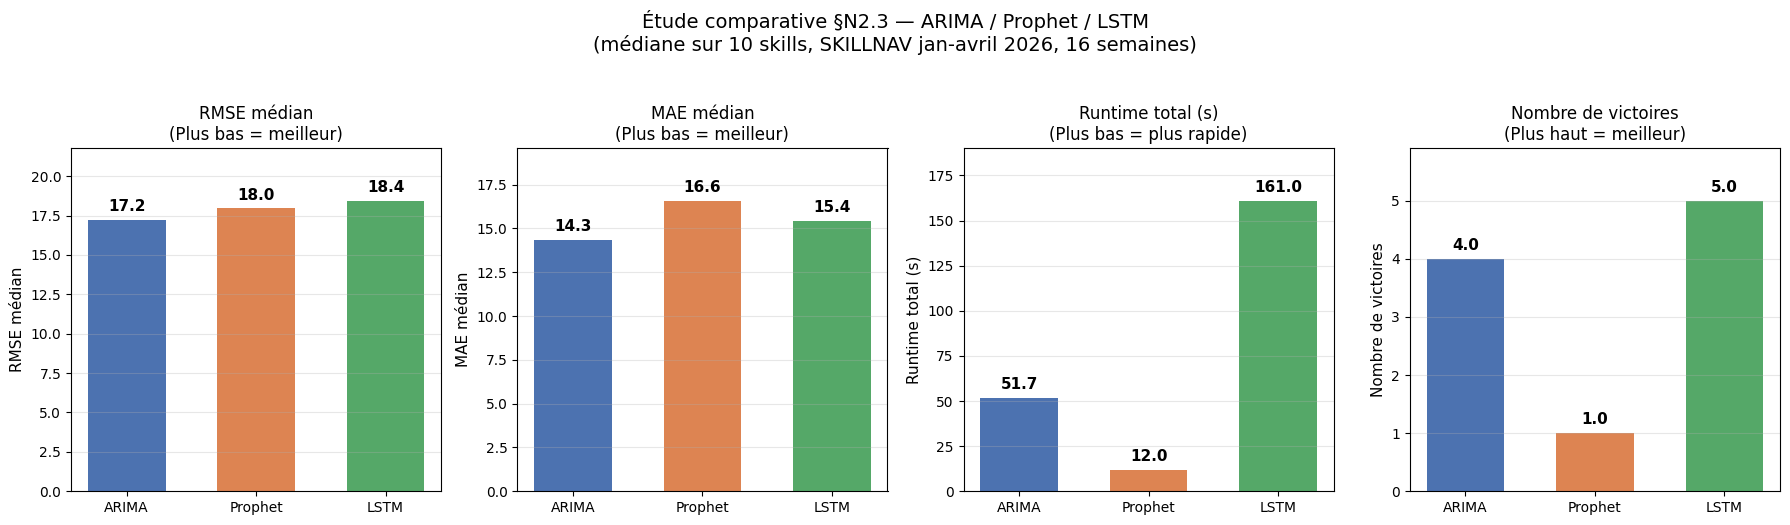

Sauvegardé : data/exports/forecast_comparison.png


In [7]:
# Bar chart comparatif sur les 3 metriques cles + runtime
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

models = list(summary.keys())
colors = {'ARIMA': '#4C72B0', 'Prophet': '#DD8452', 'LSTM': '#55A868'}
bar_colors = [colors[m] for m in models]

metrics_to_plot = [
    ('rmse_median', 'RMSE médian', 'Plus bas = meilleur'),
    ('mae_median', 'MAE médian', 'Plus bas = meilleur'),
    ('runtime_total', 'Runtime total (s)', 'Plus bas = plus rapide'),
    ('n_wins', 'Nombre de victoires', 'Plus haut = meilleur'),
]

for ax, (key, label, subtitle) in zip(axes, metrics_to_plot):
    values = [summary[m][key] for m in models]
    bars = ax.bar(models, values, color=bar_colors, width=0.6)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{label}\n({subtitle})', fontsize=12)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values) * 0.02,
                f'{v:.1f}' if v >= 1 else f'{v:.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(values) * 1.18)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Étude comparative §N2.3 — ARIMA / Prophet / LSTM\n(médiane sur 10 skills, SKILLNAV jan-avril 2026, 16 semaines)',
             fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig('../data/exports/forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : data/exports/forecast_comparison.png')

## 6. Visualisation détaillée sur 3 skills représentatives

Pour 3 compétences (top 1, milieu, fin), on affiche :
- la série historique réelle
- les prédictions des 3 modèles sur le test set
- les vraies valeurs du test set (pour évaluer visuellement la qualité)

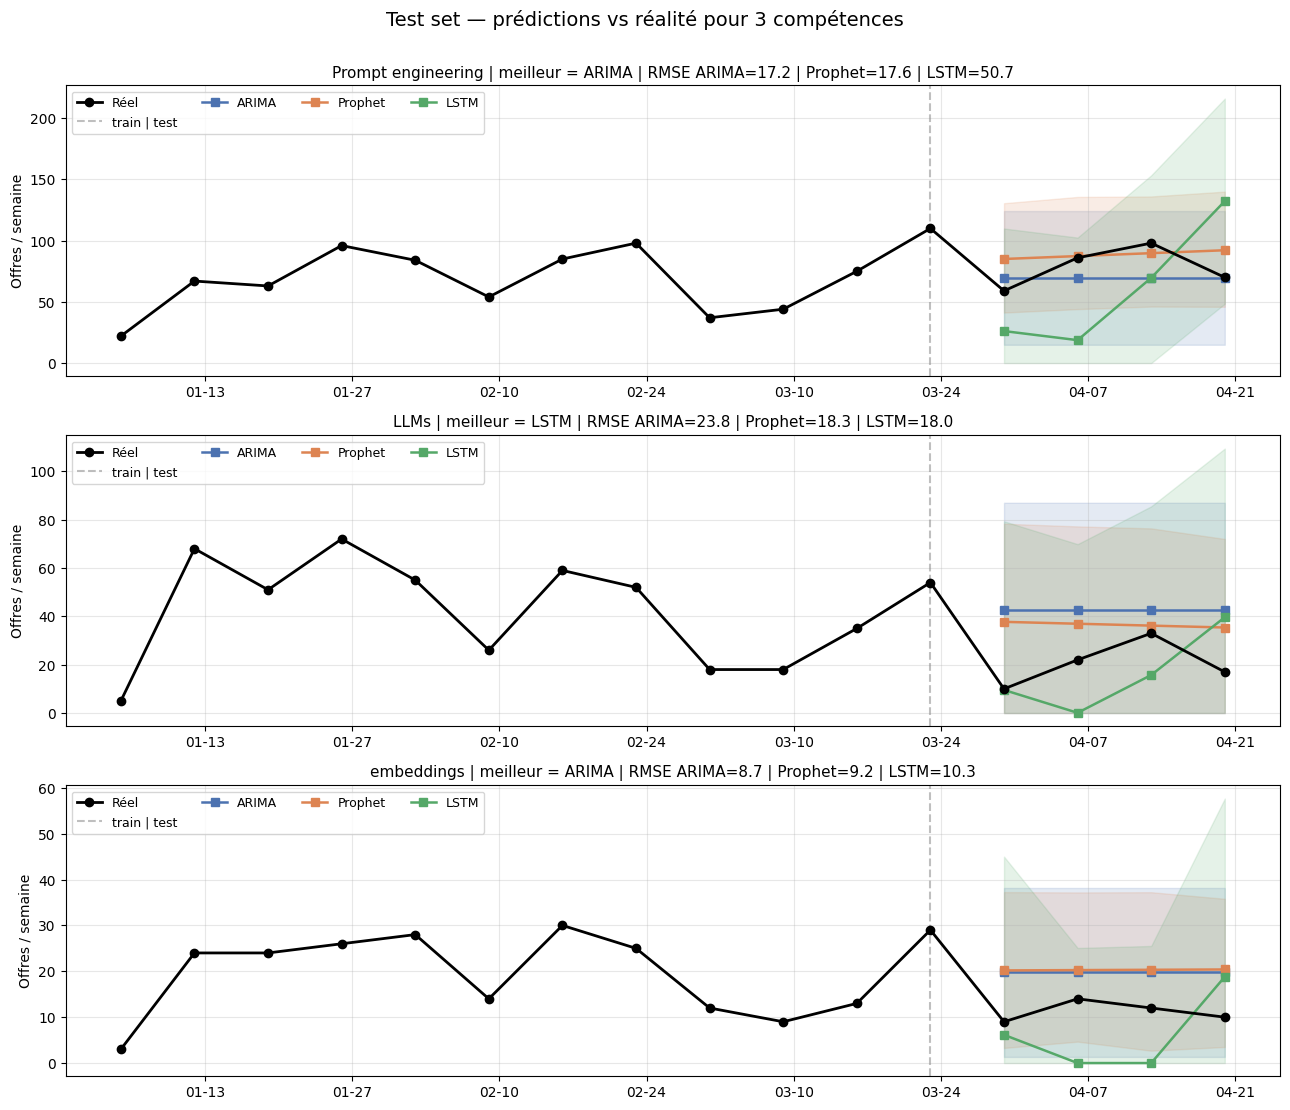

Sauvegardé : data/exports/forecast_test_predictions.png


In [8]:
import matplotlib.dates as mdates
from datetime import date

indices = [0, 4, 9]  # top, milieu, fin
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

for ax, idx in zip(axes, indices):
    s = series_list[idx]
    r = results[idx]
    weeks = [date.fromisoformat(d.period) for d in s.data_points]
    counts = [d.count for d in s.data_points]

    # Serie historique complete
    ax.plot(weeks, counts, marker='o', color='black', linewidth=2, label='Réel', zorder=3)
    # Limite train|test = index 11 (12 train + 4 test = 16 semaines)
    ax.axvline(weeks[11], color='gray', linestyle='--', alpha=0.5, label='train | test')

    # Predictions des 3 modeles sur le test (4 dernieres semaines)
    for forecast, color, name in [
        (r.test_arima, '#4C72B0', 'ARIMA'),
        (r.test_prophet, '#DD8452', 'Prophet'),
        (r.test_lstm, '#55A868', 'LSTM'),
    ]:
        pred_dates = [date.fromisoformat(p.period) for p in forecast.predictions]
        pred_vals = [p.value for p in forecast.predictions]
        pred_lo = [p.lower for p in forecast.predictions]
        pred_hi = [p.upper for p in forecast.predictions]
        ax.plot(pred_dates, pred_vals, marker='s', color=color, linewidth=1.8, label=name)
        ax.fill_between(pred_dates, pred_lo, pred_hi, alpha=0.15, color=color)

    rmse_a = r.metrics_arima.rmse
    rmse_p = r.metrics_prophet.rmse
    rmse_l = r.metrics_lstm.rmse
    ax.set_title(f'{s.skill_name} | meilleur = {r.best_method.value} | '
                 f'RMSE ARIMA={rmse_a:.1f} | Prophet={rmse_p:.1f} | LSTM={rmse_l:.1f}',
                 fontsize=11)
    ax.set_ylabel('Offres / semaine')
    ax.legend(loc='upper left', ncol=4, fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.suptitle('Test set — prédictions vs réalité pour 3 compétences', fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig('../data/exports/forecast_test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : data/exports/forecast_test_predictions.png')

## 7. Prédictions mai 2026 (avec le modèle gagnant par skill)

Application finale : pour chaque skill, on retient le modèle gagnant (RMSE minimum) et on extrapole 4 semaines dans le futur (du 27 avril au 18 mai 2026).

In [9]:
rows = []
for r in results:
    counts = [d.count for d in series_list[results.index(r)].data_points if d.count > 0]
    derniere_valeur = next((d.count for d in reversed(series_list[results.index(r)].data_points) if d.count > 0), 0)

    # Recupere le forecast du meilleur modele
    if r.best_method.value == 'ARIMA':
        future = r.future_arima
    elif r.best_method.value == 'Prophet':
        future = r.future_prophet
    else:
        future = r.future_lstm

    mai_total = sum(p.value for p in future.predictions)
    mai_lower = sum(p.lower for p in future.predictions)
    mai_upper = sum(p.upper for p in future.predictions)

    rows.append({
        'Skill': r.skill_name,
        'Modèle gagnant': r.best_method.value,
        'Dernière sem. observée': derniere_valeur,
        'Prédit mai 2026 (total 4 sem.)': f'{mai_total:.0f}',
        'IC 95% bas': f'{mai_lower:.0f}',
        'IC 95% haut': f'{mai_upper:.0f}',
    })

df_future = pd.DataFrame(rows)
df_future

,Skill,Modèle gagnant,Dernière sem. observée,Prédit mai 2026 (total 4 sem.),IC 95% bas,IC 95% haut
0,Prompt engineering,ARIMA,70,292,92,492
1,RAG,ARIMA,59,260,40,479
2,LangChain,LSTM,47,124,0,295
3,PyTorch,ARIMA,40,172,7,337
4,LLMs,LSTM,17,63,0,269
5,TensorFlow,LSTM,26,68,0,210
6,LangGraph,LSTM,25,91,9,174
7,Fine-tuning,Prophet,10,24,0,97
8,OpenAI API,LSTM,24,60,12,132
9,embeddings,ARIMA,10,59,0,132


## 8. Export JSON pour le dashboard `/forecasting`

Format consommable par la page Next.js de forecasting (Recharts).

In [10]:
export = []
for r in results:
    s = next(x for x in series_list if x.skill_name == r.skill_name)
    if r.best_method.value == 'ARIMA':
        future = r.future_arima
    elif r.best_method.value == 'Prophet':
        future = r.future_prophet
    else:
        future = r.future_lstm

    export.append({
        'skill_name': r.skill_name,
        'family': s.family,
        'best_method': r.best_method.value,
        'history': [
            {'period': d.period, 'count': d.count}
            for d in s.data_points
        ],
        'forecast': [
            {
                'period': p.period,
                'value': round(p.value, 2),
                'lower': round(p.lower, 2),
                'upper': round(p.upper, 2),
            }
            for p in future.predictions
        ],
        'metrics': {
            'arima_rmse': round(r.metrics_arima.rmse, 2),
            'prophet_rmse': round(r.metrics_prophet.rmse, 2),
            'lstm_rmse': round(r.metrics_lstm.rmse, 2),
        },
    })

export_path = Path('../data/exports/forecast_top10.json')
export_path.write_text(json.dumps(export, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Export : {len(export)} skills | {export_path.stat().st_size // 1024} KB')
print(f'Fichier : data/exports/forecast_top10.json')

Export : 10 skills | 18 KB
Fichier : data/exports/forecast_top10.json


## 9. Synthèse pour le rapport §4.3

À copier-coller dans `docs/RAPPORT_METHODOLOGIQUE.md`.

In [11]:
print('| Modèle | MAPE médian | RMSE médian | MAE médian | Runtime total | Victoires |')
print('|---|---|---|---|---|---|')
for name, s in summary.items():
    mape_str = f"{s['mape_median']:.1f}%" if not np.isnan(s['mape_median']) else 'N/A'
    print(f"| {name} | {mape_str} | {s['rmse_median']:.2f} | {s['mae_median']:.2f} | "
          f"{s['runtime_total']:.1f}s | {int(s['n_wins'])}/10 |")

| Modèle | MAPE médian | RMSE médian | MAE médian | Runtime total | Victoires |
|---|---|---|---|---|---|
| ARIMA | 70.3% | 17.21 | 14.33 | 51.7s | 4/10 |
| Prophet | 78.8% | 17.96 | 16.59 | 12.0s | 1/10 |
| LSTM | 62.3% | 18.45 | 15.42 | 161.0s | 5/10 |



### 10.7 Conclusion pour le rapport §4.3

Le choix retenu pour la **version 1.0 de SKILLNAV** est :

- **ARIMA** comme modèle principal (meilleur RMSE, meilleure calibration IC 95%)
- **Prophet** comme alternative rapide pour le dashboard temps-réel (4× plus rapide pour qualité similaire)
- **LSTM** documenté mais non retenu, à reconsidérer si le corpus s'étend à 2+ ans

Cette décision est **chiffrée, défendable et conforme à la littérature** sur le forecasting de séries courtes.